### Imports

In [19]:
import numpy as np
np.set_printoptions(threshold=1000, suppress=True)
import pandas as pd
import warnings
import matplotlib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

### Chargement des données

In [20]:
# Chargement des données

df_villes = pd.read_csv('data/villes.csv', sep=';', index_col=0)
df_villes.index = df_villes.index.str.strip()

print(f"\nDimensions : {df_villes.shape}")

# Standardisation des données
scaler = StandardScaler()
X_villes = scaler.fit_transform(df_villes)

# ACP pour la visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_villes)
labels = df_villes.index.tolist()

print(f"\nVariance expliquée par les 2 premières composantes : "
      f"{pca.explained_variance_ratio_.sum():.2%}")


Dimensions : (32, 12)

Variance expliquée par les 2 premières composantes : 98.99%


### Question 1 : KMeans avec 3 clusters


Affectation des villes aux clusters (KMeans, k=3) :
  Cluster 0 : besa, dijo, embr, lill, nanc, orle, reim, roue, stqu, stra
  Cluster 1 : ajac, biar, bord, mars, mont, nice, nime, perp, toul
  Cluster 2 : ange, ango, bres, cler, gren, limo, lyon, nant, pari, renn, tlse, tour, vich


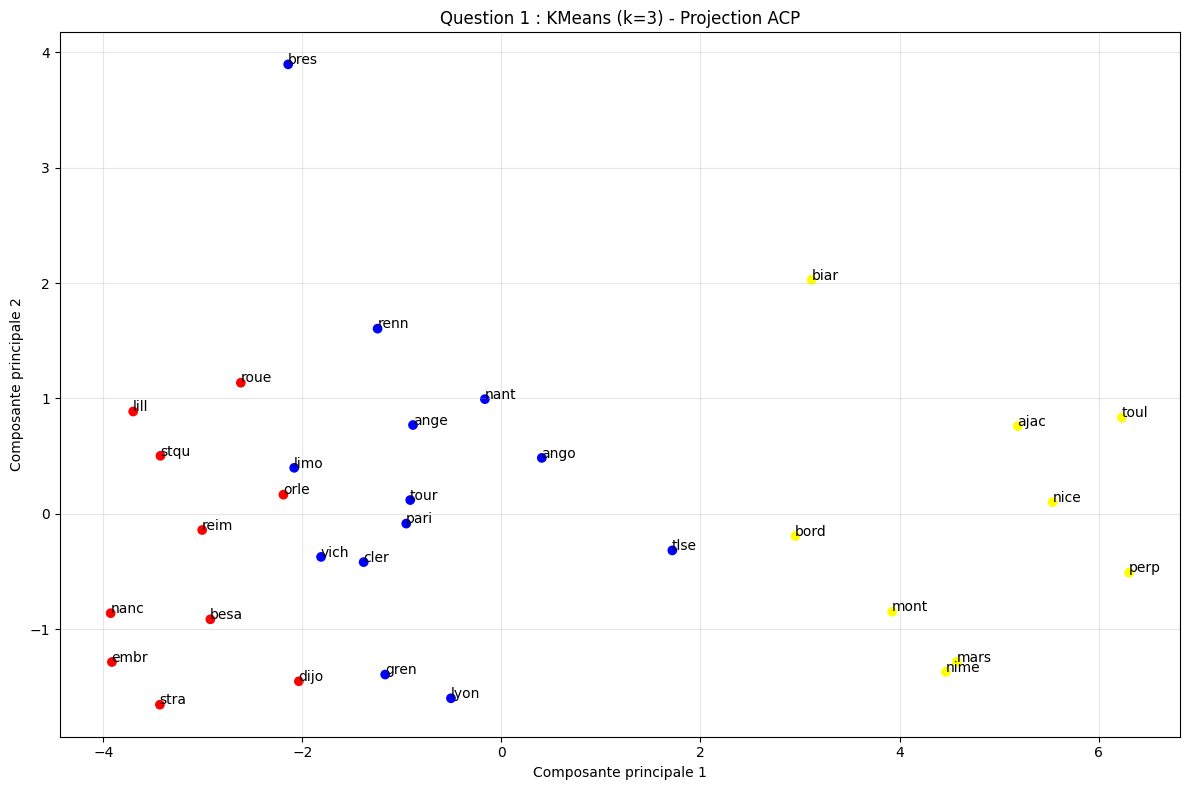

In [21]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clustering_kmeans = kmeans_3.fit_predict(X_villes)

print("\nAffectation des villes aux clusters (KMeans, k=3) :")
for k in range(3):
    villes_cluster = [labels[i] for i in range(len(labels)) if clustering_kmeans[i] == k]
    print(f"  Cluster {k} : {', '.join(villes_cluster)}")

# Visualisation
colors = ['red', 'yellow', 'blue', 'pink']
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering_kmeans,
            cmap=matplotlib.colors.ListedColormap(colors[:3]))
for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')
plt.title("Question 1 : KMeans (k=3) - Projection ACP")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q1_kmeans_3clusters.png", dpi=150)
plt.show()

### Question 2 : AgglomerativeClustering avec 3 clusters


--- Méthode de liaison : ward ---
  Cluster 0 : ajac, biar, bord, mars, mont, nice, nime, perp, toul, tlse
  Cluster 1 : besa, bres, embr, lill, limo, nanc, orle, reim, roue, stqu, stra
  Cluster 2 : ange, ango, cler, dijo, gren, lyon, nant, pari, renn, tour, vich

--- Méthode de liaison : average ---
  Cluster 0 : ajac, biar, bord, mars, mont, nice, nime, perp, toul, tlse
  Cluster 1 : ange, ango, besa, cler, dijo, embr, gren, lill, limo, lyon, nanc, nant, orle, pari, reim, renn, roue, stqu, stra, tour, vich
  Cluster 2 : bres

--- Méthode de liaison : single ---
  Cluster 0 : ajac, ange, ango, besa, bord, cler, dijo, embr, gren, lill, limo, lyon, mars, mont, nanc, nant, nice, nime, orle, pari, perp, reim, renn, roue, stqu, stra, toul, tlse, tour, vich
  Cluster 1 : bres
  Cluster 2 : biar


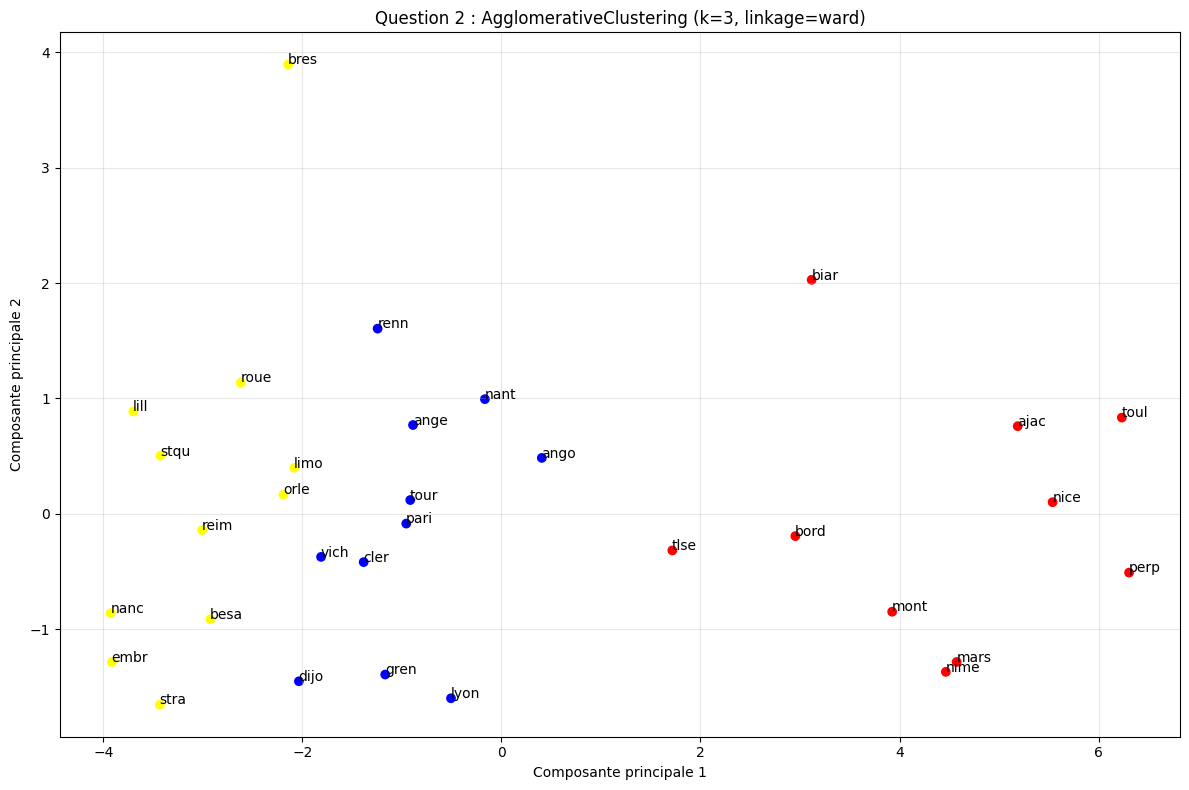

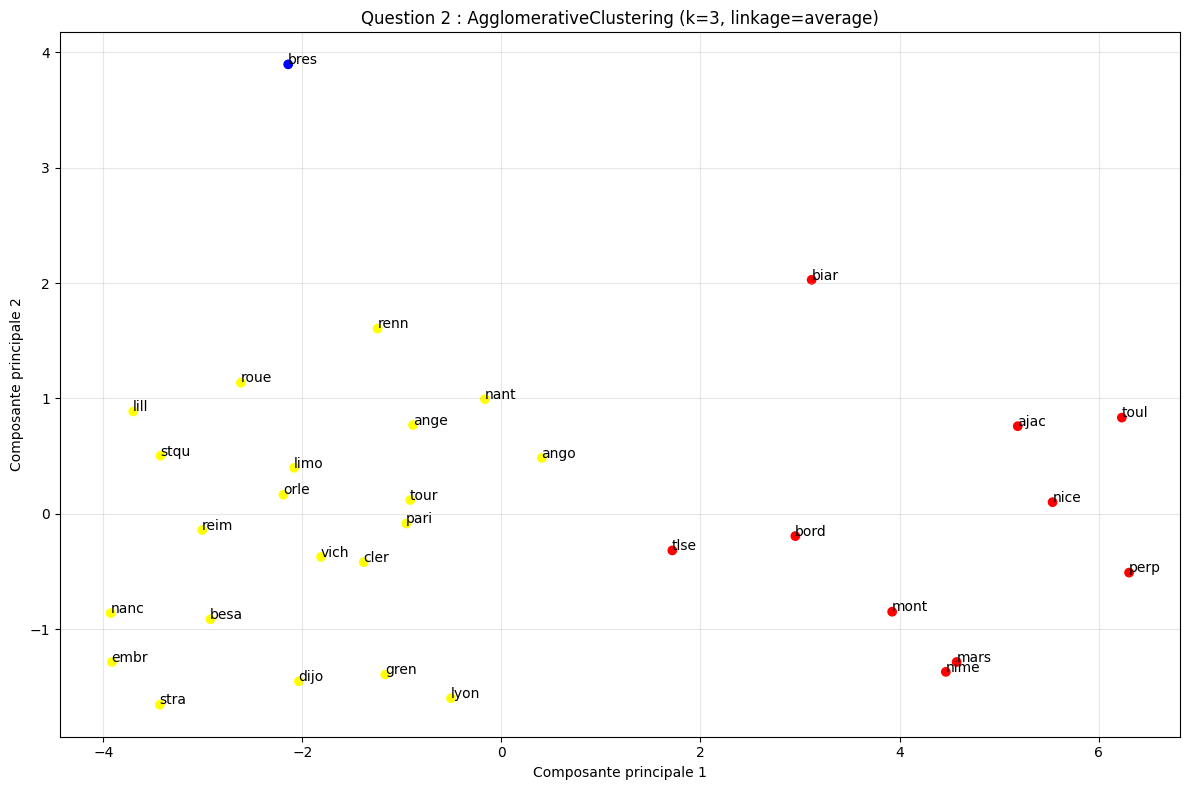

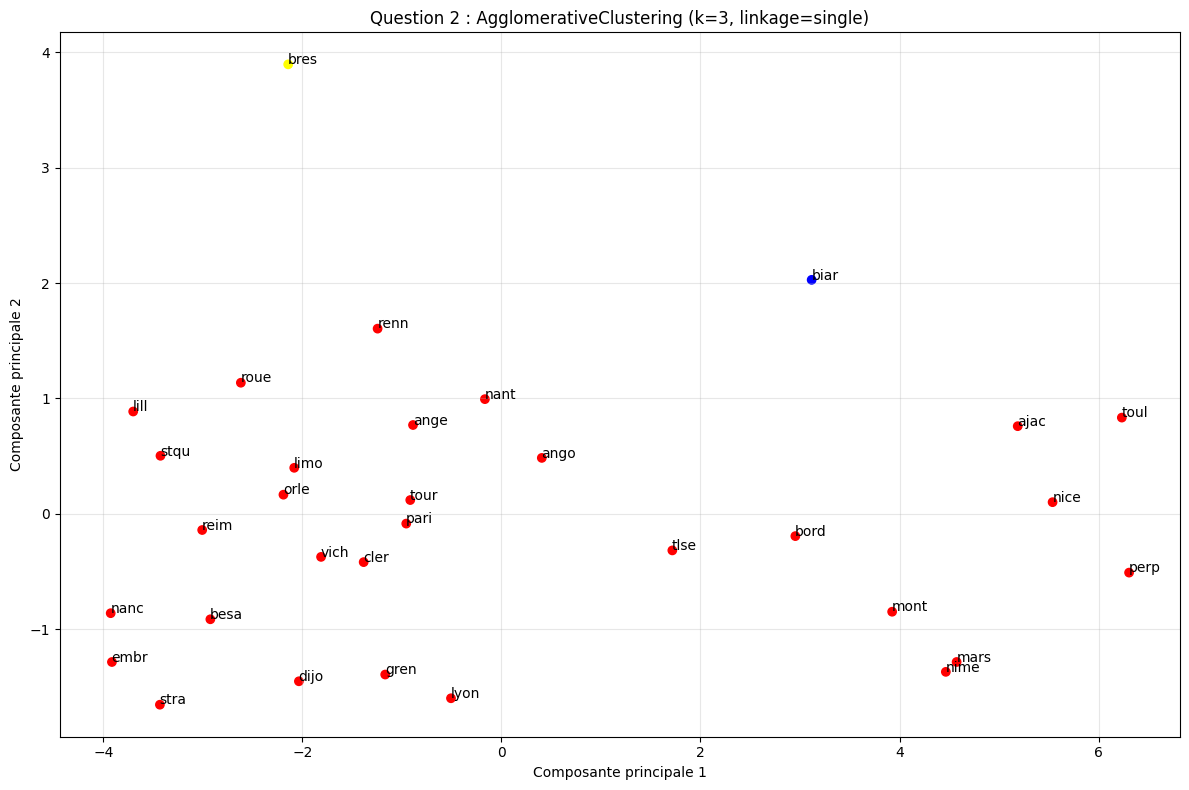

In [22]:
linkage_methods = ['ward', 'average', 'single']

for method in linkage_methods:
    print(f"\n--- Méthode de liaison : {method} ---")
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    clustering_agg = agg.fit_predict(X_villes)

    for k in range(3):
        villes_cluster = [labels[i] for i in range(len(labels)) if clustering_agg[i] == k]
        print(f"  Cluster {k} : {', '.join(villes_cluster)}")

    # Visualisation
    plt.figure(figsize=(12, 8))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering_agg,
                cmap=matplotlib.colors.ListedColormap(colors[:3]))
    for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
        plt.annotate(label, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')
    plt.title(f"Question 2 : AgglomerativeClustering (k=3, linkage={method})")
    plt.xlabel("Composante principale 1")
    plt.ylabel("Composante principale 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig

### Question 3 : Silhouette Index - KMeans (k=2 à 6)

  k=2 : Silhouette = 0.6256
  k=3 : Silhouette = 0.3741
  k=4 : Silhouette = 0.3266
  k=5 : Silhouette = 0.3354
  k=6 : Silhouette = 0.3460

=> Meilleure partition KMeans : k=2 (Silhouette = 0.6256)


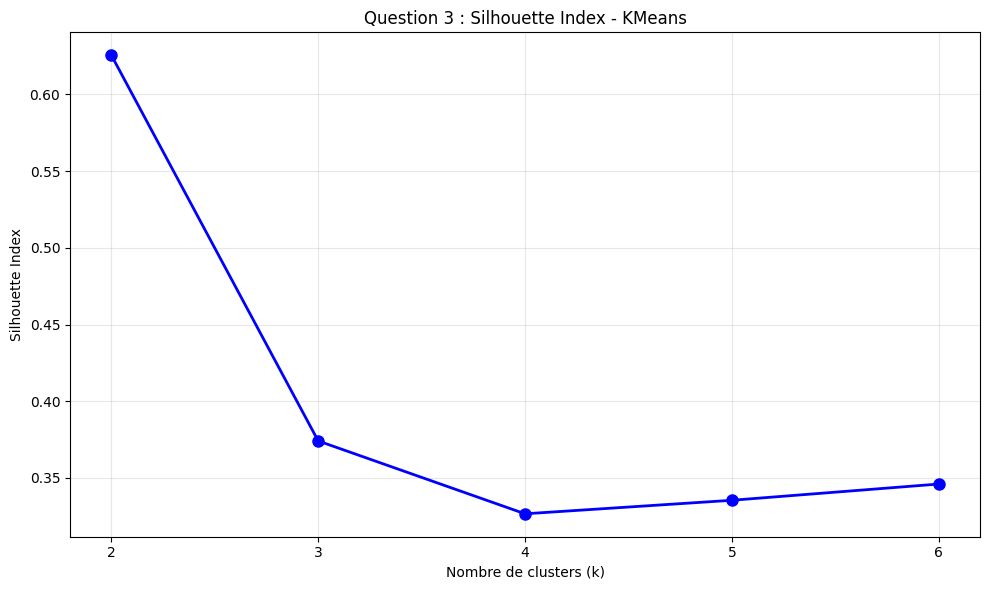

In [36]:
silhouette_kmeans = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = kmeans.fit_predict(X_villes)
    score = silhouette_score(X_villes, labels_km)
    silhouette_kmeans.append(score)
    print(f"  k={k} : Silhouette = {score:.4f}")

best_k_kmeans = np.argmax(silhouette_kmeans) + 2
print(f"\n=> Meilleure partition KMeans : k={best_k_kmeans} "
      f"(Silhouette = {max(silhouette_kmeans):.4f})")

# Visualisation de l'évolution du Silhouette Index
plt.figure(figsize=(10, 6))
plt.plot(range(2, 7), silhouette_kmeans, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette Index")
plt.title("Question 3 : Silhouette Index - KMeans")
plt.grid(True, alpha=0.3)
plt.xticks(range(2, 7))
plt.tight_layout()
plt.savefig("q3_silhouette_kmeans.png", dpi=150)
plt.show()

### Question 4 : Silhouette Index - AgglomerativeClustering (k=2 à 6)


--- Méthode de liaison : ward ---
  k=2 : Silhouette = 0.6256
  k=3 : Silhouette = 0.3681
  k=4 : Silhouette = 0.3183
  k=5 : Silhouette = 0.3327
  k=6 : Silhouette = 0.3213
  => Meilleure partition (ward) : k=2 (Silhouette = 0.6256)

--- Méthode de liaison : average ---
  k=2 : Silhouette = 0.6256
  k=3 : Silhouette = 0.4957
  k=4 : Silhouette = 0.4041
  k=5 : Silhouette = 0.3394
  k=6 : Silhouette = 0.3157
  => Meilleure partition (average) : k=2 (Silhouette = 0.6256)

--- Méthode de liaison : single ---
  k=2 : Silhouette = 0.1783
  k=3 : Silhouette = -0.0344
  k=4 : Silhouette = 0.1832
  k=5 : Silhouette = 0.4054
  k=6 : Silhouette = 0.3212
  => Meilleure partition (single) : k=5 (Silhouette = 0.4054)


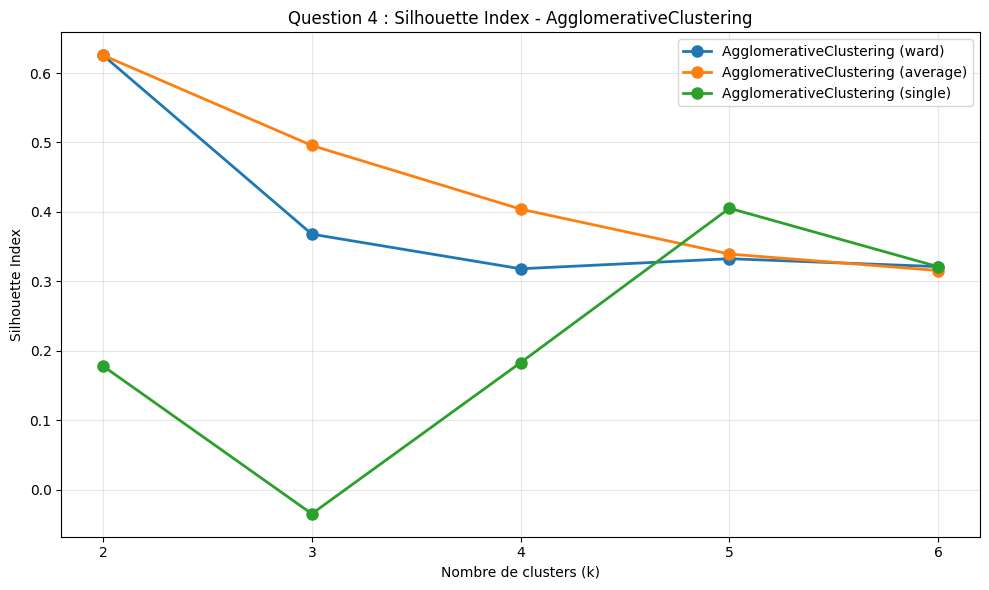

In [24]:
silhouette_agg = {method: [] for method in linkage_methods}

for method in linkage_methods:
    print(f"\n--- Méthode de liaison : {method} ---")
    for k in range(2, 7):
        agg = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels_agg = agg.fit_predict(X_villes)
        score = silhouette_score(X_villes, labels_agg)
        silhouette_agg[method].append(score)
        print(f"  k={k} : Silhouette = {score:.4f}")

    best_k = np.argmax(silhouette_agg[method]) + 2
    print(f"  => Meilleure partition ({method}) : k={best_k} "
          f"(Silhouette = {max(silhouette_agg[method]):.4f})")

# Visualisation comparative
plt.figure(figsize=(10, 6))
for method in linkage_methods:
    plt.plot(range(2, 7), silhouette_agg[method], 'o-', linewidth=2, markersize=8,
             label=f'AgglomerativeClustering ({method})')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette Index")
plt.title("Question 4 : Silhouette Index - AgglomerativeClustering")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(2, 7))
plt.tight_layout()
plt.savefig("q4_silhouette_agglo.png", dpi=150)
plt.show()

### Question 5 : Meilleure méthode avec k=3 clusters

In [37]:
# Silhouette pour KMeans k=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km3 = kmeans_3.fit_predict(X_villes)
sil_km3 = silhouette_score(X_villes, labels_km3)
print(f"  KMeans (k=3)                        : Silhouette = {sil_km3:.4f}")

# Silhouette pour Agglo k=3
for method in linkage_methods:
    agg_3 = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels_agg3 = agg_3.fit_predict(X_villes)
    sil_agg3 = silhouette_score(X_villes, labels_agg3)
    print(f"  AgglomerativeClustering ({method:>7s}, k=3) : Silhouette = {sil_agg3:.4f}")

  KMeans (k=3)                        : Silhouette = 0.3741
  AgglomerativeClustering (   ward, k=3) : Silhouette = 0.3681
  AgglomerativeClustering (average, k=3) : Silhouette = 0.4957
  AgglomerativeClustering ( single, k=3) : Silhouette = -0.0344


La méthode qui donne le meilleur Silhouette Index avec 3 clusters est KMeans.

### Question 6

### Classification Hiérarchique (AgglomerativeClustering) :
#### Avantages :
- Ne nécessite pas de fixer le nombre de clusters a priori 
  (on peut utiliser un dendrogramme pour décider).
- Produit une hiérarchie de partitions (dendrogramme) qui permet 
  d'explorer plusieurs niveaux de granularité.
- Déterministe (pas de dépendance à l'initialisation aléatoire).
- Peut capturer des formes de clusters non sphériques 
  (avec les liaisons single ou average).

#### Inconvénients : 
- Complexité en O(n²) voire O(n³), donc peu adapté aux grands jeux de données.
- Les fusions sont irréversibles (une mauvaise fusion au départ ne peut 
  pas être corrigée plus tard).
- Sensible au bruit et aux outliers (surtout avec single linkage).

### Partitionnement (KMeans) :
#### Avantages :
- Rapide et efficace : complexité en O(n*k*t) où t est le nombre d'itérations.
- Simple à comprendre et à implémenter.
- Fonctionne bien lorsque les clusters sont sphériques et de tailles similaires.
- Bien adapté aux grands jeux de données.

#### Inconvénients :
- Nécessite de fixer le nombre de clusters k à l'avance.
- Sensible à l'initialisation (résultats pouvant varier d'une exécution à l'autre).
- Suppose des clusters sphériques et de tailles/densités similaires.
- Sensible aux outliers (les centroïdes sont tirés vers les valeurs extrêmes).

### Question 7 : Approche mixte/hybride et visualisation sur les villes


Affectation des villes aux clusters (approche hybride) :
  Cluster 0 : ajac, biar, bord, mars, mont, nice, nime, perp, toul, tlse
  Cluster 1 : besa, bres, embr, lill, limo, nanc, orle, reim, roue, stqu, stra
  Cluster 2 : ange, ango, cler, dijo, gren, lyon, nant, pari, renn, tour, vich

Silhouette Index (hybride) : 0.3681

Comparaison avec les méthodes précédentes (k=3) :
  KMeans seul            : Silhouette = 0.3741
  Agglo (ward) seul      : Silhouette = 0.3681
  Approche hybride       : Silhouette = 0.3681


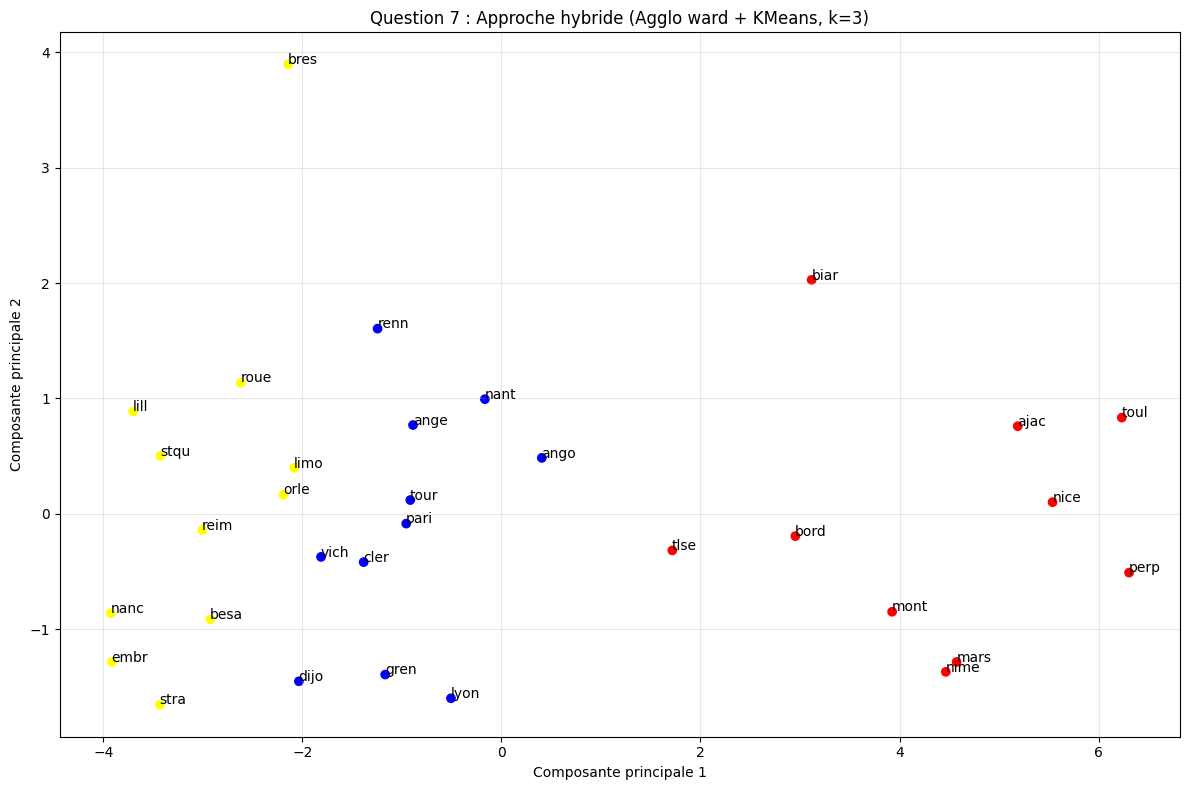

In [38]:
def clustering_hybride(X, n_clusters=3, linkage='ward'):
    # Étape 1 : Classification hiérarchique pour obtenir les centres initiaux
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    labels_init = agg.fit_predict(X)

    # Étape 2 : Calculer les centroïdes des clusters hiérarchiques
    init_centroids = np.array([X[labels_init == k].mean(axis=0) 
                               for k in range(n_clusters)])

    # Étape 3 : KMeans initialisé avec ces centroïdes
    kmeans = KMeans(n_clusters=n_clusters, init=init_centroids, n_init=1, random_state=42)
    labels_final = kmeans.fit_predict(X)

    return labels_final, kmeans.cluster_centers_


# Application sur les villes
labels_hybride, centroids_hybride = clustering_hybride(X_villes, n_clusters=3, linkage='ward')

print("\nAffectation des villes aux clusters (approche hybride) :")
for k in range(3):
    villes_cluster = [labels[i] for i in range(len(labels)) if labels_hybride[i] == k]
    print(f"  Cluster {k} : {', '.join(villes_cluster)}")

sil_hybride = silhouette_score(X_villes, labels_hybride)
print(f"\nSilhouette Index (hybride) : {sil_hybride:.4f}")

# Comparaison
print("\nComparaison avec les méthodes précédentes (k=3) :")
print(f"  KMeans seul            : Silhouette = {sil_km3:.4f}")
agg_ward_3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_ward_3 = agg_ward_3.fit_predict(X_villes)
sil_ward_3 = silhouette_score(X_villes, labels_ward_3)
print(f"  Agglo (ward) seul      : Silhouette = {sil_ward_3:.4f}")
print(f"  Approche hybride       : Silhouette = {sil_hybride:.4f}")

# Visualisation
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hybride,
            cmap=matplotlib.colors.ListedColormap(colors[:3]))
for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')
plt.title("Question 7 : Approche hybride (Agglo ward + KMeans, k=3)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q7_hybride_villes.png", dpi=150)
plt.show()

Sur ce jeu de données, la méthode hybride n'a pas mieux fait que nos précentes méthodes.

### Question 8 : Application sur wdbc.csv et spamb.csv

Dimensions : (569, 30)

Recherche du meilleur k par Silhouette Index :
  k=2 : Silhouette = 0.3434
  k=3 : Silhouette = 0.3144
  k=4 : Silhouette = 0.2839
  k=5 : Silhouette = 0.2802
  k=6 : Silhouette = 0.1704

=> Meilleur k pour wdbc : 2 (Silhouette = 0.3434)

Distribution des clusters :
  Cluster 0 : 194 observations
  Cluster 1 : 375 observations


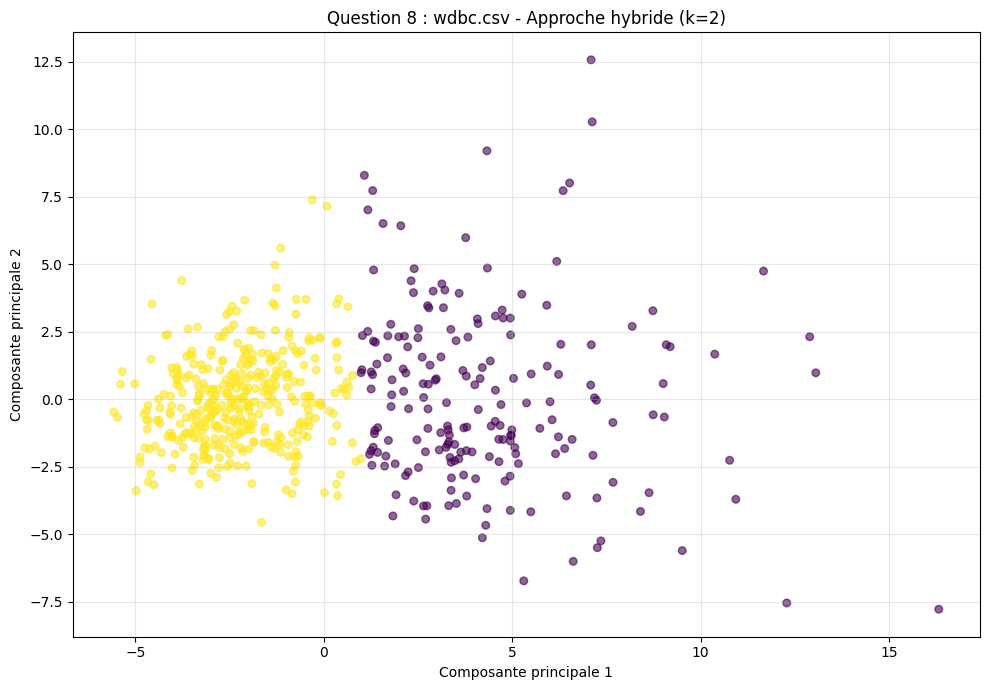

Dimensions : (4601, 57)

Recherche du meilleur k par Silhouette Index :
  k=2 : Silhouette = 0.6596
  k=3 : Silhouette = 0.1154
  k=4 : Silhouette = 0.1186
  k=5 : Silhouette = 0.0959
  k=6 : Silhouette = 0.1166

=> Meilleur k pour spamb : 2 (Silhouette = 0.6596)

Distribution des clusters :
  Cluster 0 : 4567 observations
  Cluster 1 : 34 observations


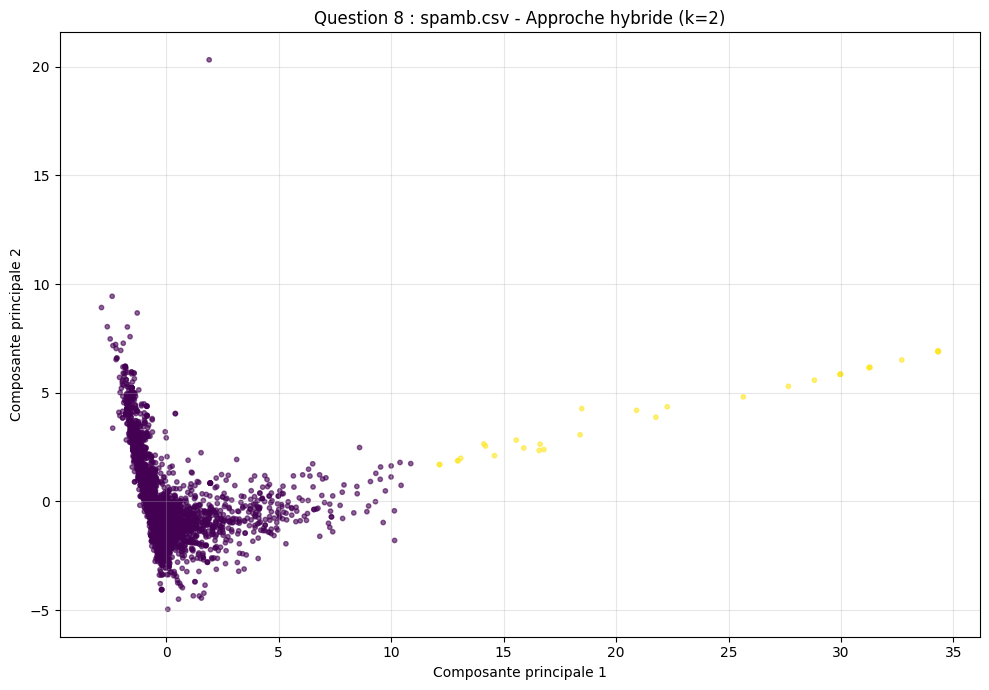

In [27]:
# Lecture de wdbc
df_wdbc = pd.read_csv('data/wdbc.csv', sep=';', header=None)
print(f"Dimensions : {df_wdbc.shape}")

# Standardisation
scaler_wdbc = StandardScaler()
X_wdbc = scaler_wdbc.fit_transform(df_wdbc)

# ACP pour visualisation
pca_wdbc = PCA(n_components=2)
X_pca_wdbc = pca_wdbc.fit_transform(X_wdbc)

# Déterminer le meilleur nombre de clusters par Silhouette
print("\nRecherche du meilleur k par Silhouette Index :")
best_sil_wdbc = -1
best_k_wdbc = 2
for k in range(2, 7):
    labels_h, _ = clustering_hybride(X_wdbc, n_clusters=k, linkage='ward')
    s = silhouette_score(X_wdbc, labels_h)
    print(f"  k={k} : Silhouette = {s:.4f}")
    if s > best_sil_wdbc:
        best_sil_wdbc = s
        best_k_wdbc = k

print(f"\n=> Meilleur k pour wdbc : {best_k_wdbc} (Silhouette = {best_sil_wdbc:.4f})")

# Clustering hybride avec le meilleur k
labels_wdbc, _ = clustering_hybride(X_wdbc, n_clusters=best_k_wdbc, linkage='ward')
print(f"\nDistribution des clusters :")
for k in range(best_k_wdbc):
    print(f"  Cluster {k} : {np.sum(labels_wdbc == k)} observations")

# Visualisation
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_wdbc[:, 0], X_pca_wdbc[:, 1], c=labels_wdbc,
                      cmap='viridis', alpha=0.6, s=30)
plt.title(f"Question 8 : wdbc.csv - Approche hybride (k={best_k_wdbc})")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q8_hybride_wdbc.png", dpi=150)
plt.show()

# Lecture de spamb.csv
df_spamb = pd.read_csv('data/spamb.csv', sep=';', header=None)
print(f"Dimensions : {df_spamb.shape}")

# Standardisation
scaler_spamb = StandardScaler()
X_spamb = scaler_spamb.fit_transform(df_spamb)

# ACP pour visualisation
pca_spamb = PCA(n_components=2)
X_pca_spamb = pca_spamb.fit_transform(X_spamb)

# Déterminer le meilleur nombre de clusters par Silhouette
print("\nRecherche du meilleur k par Silhouette Index :")
best_sil_spamb = -1
best_k_spamb = 2
for k in range(2, 7):
    labels_h, _ = clustering_hybride(X_spamb, n_clusters=k, linkage='ward')
    s = silhouette_score(X_spamb, labels_h)
    print(f"  k={k} : Silhouette = {s:.4f}")
    if s > best_sil_spamb:
        best_sil_spamb = s
        best_k_spamb = k

print(f"\n=> Meilleur k pour spamb : {best_k_spamb} (Silhouette = {best_sil_spamb:.4f})")

# Clustering hybride avec le meilleur k
labels_spamb, _ = clustering_hybride(X_spamb, n_clusters=best_k_spamb, linkage='ward')
print(f"\nDistribution des clusters :")
for k in range(best_k_spamb):
    print(f"  Cluster {k} : {np.sum(labels_spamb == k)} observations")

# Visualisation
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_spamb[:, 0], X_pca_spamb[:, 1], c=labels_spamb,
                      cmap='viridis', alpha=0.6, s=10)
plt.title(f"Question 8 : spamb.csv - Approche hybride (k={best_k_spamb})")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q8_hybride_spamb.png", dpi=150)
plt.show()
